# 2D Stack Size Distributions Notebook

Reads frames from MD simulations, finds stacks and calculates size distributions 

In [1]:
import numpy as np
import os
import sys
cwd = os.getcwd()
itop=cwd.find("cgshells/")+len("cgshells")
PROJECT_ROOT = cwd[:itop]
sys.path.insert(0, PROJECT_ROOT )

import gzip
from scipy.spatial import KDTree
from utils.readsim import ReadSim
# from utils.curvsim.v1.curvamer2d import Curvamer2D
# from utils.curvsim.v1.curvamer3d import Curvamer3D

import matplotlib as mpl
import matplotlib.pyplot as plt
import time
from scipy.optimize import curve_fit

%matplotlib inline

def find_midlayer_pt(result,frame):
    nshells = np.max(result.dump_mol)    # number of molecules in simulation
    molatoms = result.natoms/nshells    # number of atoms per molecule
    
    ri = []
    vi = []
    for i in np.arange(nshells):
        mol = i+1
        aid1 = int(molatoms/4 + (mol - 1)*molatoms)    # id of middle-most atom in bottom layer 
        aid2 = int(3*molatoms/4 + (mol - 1)*molatoms)    # id of middle-most atom in top layer 
        mask = (result.dump_mol[frame]==mol)    # molecule mask
        a1mask = (result.dump_id[frame][mask]==aid1)
        a2mask = (result.dump_id[frame][mask]==aid2)
        r1 = np.array([result.dump_x[frame][mask][a1mask][0], # position of bottom atom
                       result.dump_y[frame][mask][a1mask][0]])
        r2 = np.array([result.dump_x[frame][mask][a2mask][0],    # position of top atom
               result.dump_y[frame][mask][a2mask][0]])
        zdist = np.sqrt(np.sum((r2-r1)**2))
        vmol = (r2-r1)/zdist    # molecule orientation vector
        rmol = r1 + 0.5*zdist*vmol    # position of molecule center
        ri.append(rmol.tolist())
        vi.append(vmol.tolist())
    return np.array(ri), np.array(vi)

def find_stacks(result,frame,rcut):
    # returns list of aggregates 
    # result must have read dumpfile already

    nshells = np.max(result.dump_mol)
    box_x = result.xhi - result.xlo
    box_y = result.yhi - result.ylo
    rshift = 0.5*np.array(box_x,box_y)    # shift points so that box starts at (0,0)
    rm, vm = find_midlayer_pt(result,frame)
    tree = KDTree(rm+rshift,boxsize=2*rshift)
    
    done = []
    aggs = []
    for i in np.arange(nshells,dtype=int):    # Note: rm[0] is mol = 1 in LAMMPS
        if i not in done:
            done.append(i)
            agg_i = [i]    # indeces of molecules in same aggregate as mol i (i = index, not molid)
            ni_indeces = tree.query_ball_point((rm+rshift)[i],rcut)
            for j in ni_indeces:
                if (j != i)and(np.sum(vm[i]*vm[j])>0):                          
                    agg_i.append(j)
                    done.append(j)
                    nj_indeces = tree.query_ball_point((rm+rshift)[j],rcut)
                    for k in nj_indeces:
                        if (k not in ni_indeces)and(np.sum(vm[k]*vm[j])>0):
                            ni_indeces.append(k)
            aggs.append(agg_i)
            
    return aggs

def molradius(result,frame,mol):

    # mol is id of molecule according to lammps (starts from 1 not zero)
        
    nshells = np.max(result.dump_mol)    # number of molecules in simulation
    molatoms = result.natoms/nshells    # number of atoms per molecule
    mask = (result.dump_mol[frame]==mol)    # selects atoms in molecule mol
    idmin = np.min(result.dump_id[frame][mask])
    minmask = (result.dump_id[frame][mask] == idmin)
    idmax = np.max(result.dump_id[frame][mask])
    maxmask = (result.dump_id[frame][mask] == idmax)
    idmid = int((idmax-idmin)/2 + idmin)
    midmask = (result.dump_id[frame][mask] == idmid)
    botmask = (result.dump_id[frame][mask]>=idmin) * (result.dump_id[frame][mask]<=idmid)    # atoms in bottom layer
    topmask = (result.dump_id[frame][mask]>idmid) * (result.dump_id[frame][mask]<=idmax)    # top layer


    # find virtual mid-layer positions
    midx = result.dump_x[frame][mask][botmask] + (result.dump_x[frame][mask][topmask] - result.dump_x[frame][mask][botmask])/2
    midy = result.dump_y[frame][mask][botmask] + (result.dump_y[frame][mask][topmask] - result.dump_y[frame][mask][botmask])/2
    midx_left = midx[0]
    midx_right = midx[-1]
    midy_left = midy[0]
    midy_right = midy[-1]
    idcenter = int(len(midx)/2)
    midx_center = midx[idcenter]
    midy_center = midy[idcenter]

    # fit circle to end points and center-most point in mid-layer
    rfit = ReadSim.fitcircle(midx_left,midy_left,midx_center,midy_center,midx_right,midy_right)
    
    return rfit

# Phase Diagrams

In [3]:
dcore = 1.0
wx = 4.9
t0 = 0.6
Nbeads = 15
# r0 = "flat"
r0 = 6.5
# r0 = 7.75
nshells = 400
sigma = 0.25
pair_ints = "1patch"
# pair_ints = "patchy"
soft_ints = 0
kh = 1000
damp = 10

eadh = -1
# ethresh = 0.2 * eadh
# ethresh = 0
ethresh = None

txtdir = "jobs/dynamics2D/distributions"

if r0 == "flat":
    filestart = f"wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}-nshells-{nshells}-r0-{r0}-sigma-{sigma:0.3f}-kh-{kh:0.3f}-pair_ints-{pair_ints}-soft_ints-{soft_ints}"
else:
    filestart = f"wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}-nshells-{nshells}-r0-{r0:0.5f}-sigma-{sigma:0.3f}-kh-{kh:0.3f}-pair_ints-{pair_ints}-soft_ints-{soft_ints}"

if ethresh == None:
    fileend = f"damp-{damp:0.2f}.txt"
else:
    fileend = f"damp-{damp:0.2f}-ethresh-{np.abs(ethresh):0.3f}.txt"

files = os.listdir(f"{PROJECT_ROOT}/{txtdir}")
matches = []
thermos = []
for f in files:
    idamp = f.index("damp")
    if (f[:len(filestart)] == filestart) and (f[idamp:] == fileend):
        matches.append(f)
        p1 = f.index("phi-") + len("phi-")
        p2 = f.index("-", p1)
        phi = float(f[p1:p2])
        t1 = f.index("kT-") + len("kT-")
        t2 = f.index("-", t1)
        kT = float(f[t1:t2])
        data_c = np.loadtxt(f"{PROJECT_ROOT}/{txtdir}/{f}")
        tsteps_c = np.array(data_c[:,0],int)
        maxsize_c = np.size(data_c[0][1:])
        hits = data_c[-1][1:]
        navg_last = np.sum(np.arange(1,len(hits)+1,1) * hits) / np.sum(hits)
        thermos.append([phi,kT,tsteps_c[-1],maxsize_c,navg_last])

thermos = np.array(thermos)
phis = thermos[:,0]
kTs = thermos[:,1]
steps = thermos[:,2]
maxsizes = thermos[:,3]
navg_lastframe = thermos[:,4]

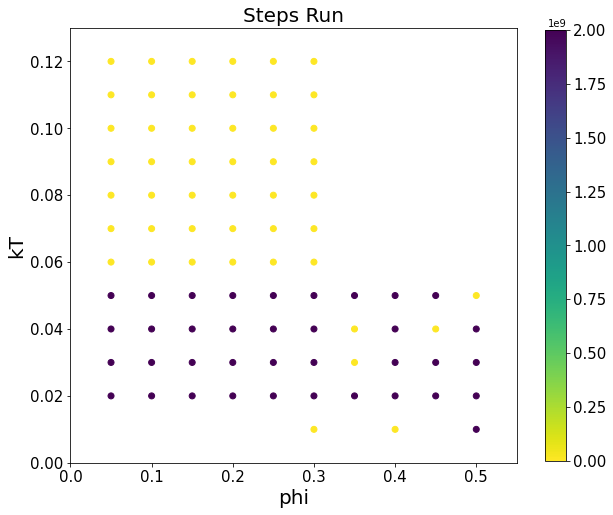

In [4]:
mylist = np.array(steps)
vmin = 0
vmax = np.max(mylist)
# vmax = 1 * 1e9
cmapname = "viridis"
orig_map=plt.cm.get_cmap(cmapname)
cmap = orig_map.reversed()

## uncomment to color simulations above vthresh (binary coloring)
vthresh = 1.7 * 1e9
truemask = (mylist >= vthresh)
mylist[truemask] = vmax
mylist[~truemask] = vmin

fig, ax = plt.subplots(1,1,figsize=(10,8))
sc = ax.scatter(phis, kTs, c = mylist, cmap = cmap, vmin = vmin, vmax = vmax)
ax.set_xlabel("phi",fontsize=20)
ax.set_ylabel("kT",fontsize=20)
ax.set_xlim(0,np.max(phis)+0.05)
ax.set_ylim(0,np.max(kTs)+0.01)
clb = plt.colorbar(sc,shrink=0.99)
ax.set_title('Steps Run',fontsize = 20)
ax.tick_params(labelsize=15)
clb.ax.tick_params(labelsize=15)

In [398]:
5*10*9

450

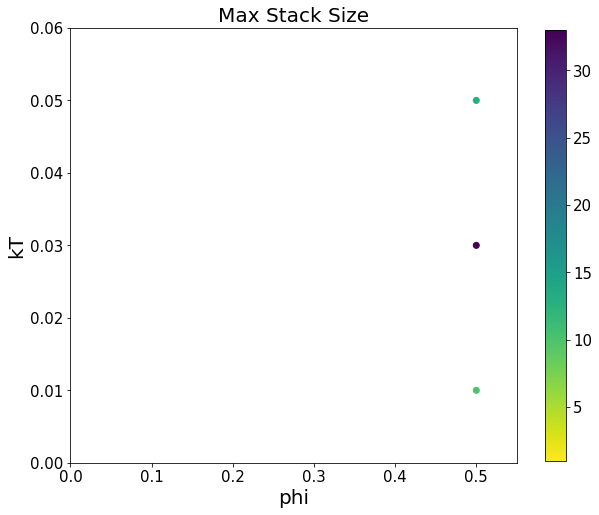

In [55]:
mylist = maxsizes
vmin = 1
vmax = np.max(mylist)
# vmax = 10
cmapname = "viridis"
orig_map=plt.cm.get_cmap(cmapname)
cmap = orig_map.reversed()

fig, ax = plt.subplots(1,1,figsize=(10,8))
sc = ax.scatter(phis, kTs, c = mylist, cmap = cmap, vmin = vmin, vmax = vmax)
ax.set_xlabel("phi",fontsize=20)
ax.set_ylabel("kT",fontsize=20)
ax.set_xlim(0,np.max(phis)+0.05)
ax.set_ylim(0,np.max(kTs)+0.01)
clb = plt.colorbar(sc,shrink=0.99)
ax.set_title('Max Stack Size',fontsize = 20)
ax.tick_params(labelsize=15)
clb.ax.tick_params(labelsize=15)

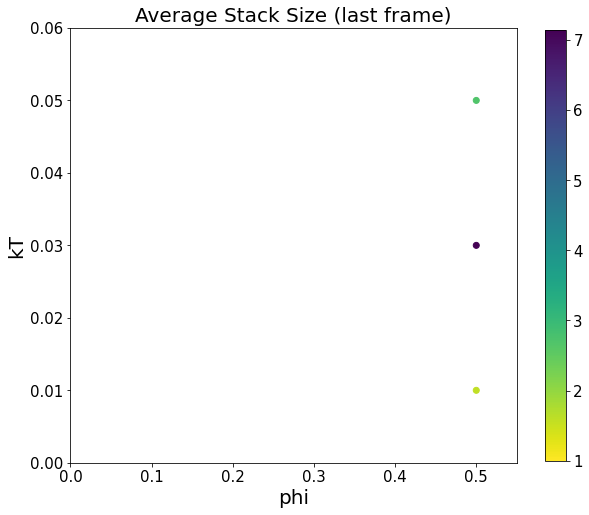

In [56]:
mylist = navg_lastframe
vmin = 1
vmax = np.max(mylist)
# vmax = 12
cmapname = "viridis"
orig_map=plt.cm.get_cmap(cmapname)
cmap = orig_map.reversed()

fig, ax = plt.subplots(1,1,figsize=(10,8))
sc = ax.scatter(phis, kTs, c = mylist, cmap = cmap, vmin = vmin, vmax = vmax)
ax.set_xlabel("phi",fontsize=20)
ax.set_ylabel("kT",fontsize=20)
ax.set_xlim(0,np.max(phis)+0.05)
ax.set_ylim(0,np.max(kTs)+0.01)
clb = plt.colorbar(sc,shrink=0.99)
ax.set_title('Average Stack Size (last frame)',fontsize = 20)
ax.tick_params(labelsize=15)
clb.ax.tick_params(labelsize=15)

In [653]:
vmax

11.764705882352942

# Text Files

In [114]:
dcore = 1.0
wx = 4.9
t0 = 0.6
Nbeads = 15
# r0 = "flat"
r0 = 6.5
# r0 = 7.75
# r0 = 9
nshells = 400
sigma = 0.25
# pair_ints = "1patch"
pair_ints = "patchy"
soft_ints = 0
kh = 1000
phi = 0.5
kT = 0.03
damp = 10

eadh = -1
ethresh = 0.3 * eadh
# ethresh = None

txtdir = "jobs/dynamics2D/distributions"

if r0 == "flat":
    filestart = f"wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}-nshells-{nshells}-r0-{r0}-sigma-{sigma:0.3f}-kh-{kh:0.3f}-pair_ints-{pair_ints}-soft_ints-{soft_ints}"
else:
    filestart = f"wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}-nshells-{nshells}-r0-{r0:0.5f}-sigma-{sigma:0.3f}-kh-{kh:0.3f}-pair_ints-{pair_ints}-soft_ints-{soft_ints}"

if ethresh == None:
    fileend = f"damp-{damp:0.2f}.txt"
else:
    fileend = f"damp-{damp:0.2f}-ethresh-{np.abs(ethresh):0.3f}.txt"    
data = np.loadtxt(f"{PROJECT_ROOT}/{txtdir}/{filestart}-phi-{phi:0.4f}-kT-{kT:0.4f}-{fileend}")
tsteps = np.array(data[:,0],int)
hits = np.array(data[:,1:],int)
maxsize = np.size(data[0][1:])

## Average Stack Size vs Time

(0.9, 10.0)

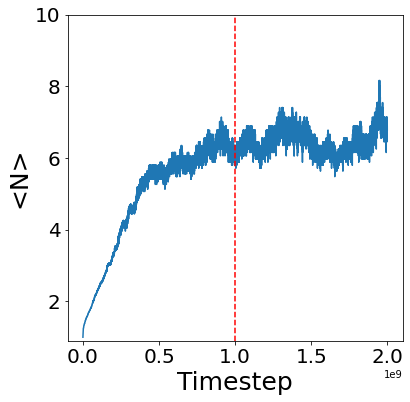

In [115]:
tstart = 1000 * 1e6

num = np.sum(np.arange(1,maxsize+1,1) * hits, axis = 1) 
den = np.sum(hits,axis = 1)
avg = num/den

fig, ax = plt.subplots(1,1,figsize=(6,6))
ax.plot(tsteps,avg)
# ax.set_title(f"Average Stack Size",fontsize=20)
ax.set_xlabel("Timestep", fontsize=25)
ax.set_ylabel("<N>",fontsize=25)
ax.tick_params(labelsize=20)
ax.vlines(tstart,ymin=0,ymax=maxsize,color='red',linestyle='dashed')

# ax.set_ylim(0.9,maxsize)
# ax.set_ylim(0.9,1.25 * avg[-1])
ax.set_ylim(0.9,10)



In [100]:
2000 * 1000000 / 100000

20000.0

## Sum Over Frames

(0.0, 70000.0)

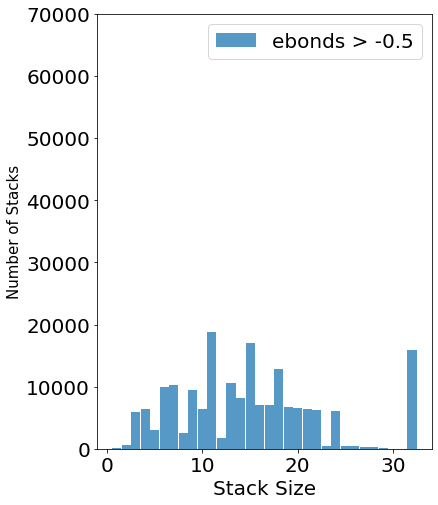

In [102]:
mask = (tsteps>=tstart)
totalhits = np.sum(hits[mask],axis=0)

bins = np.arange(0.5,maxsize+1.5,1)
fig, ax = plt.subplots(1,1,figsize=(6,8))
# ax.hist(bins[:-1],bins, weights = totalhits, rwidth=0.95)
# ax.hist(bins[:-1],bins, weights = totalhits/totalhits[0], rwidth=0.95,alpha = 0.75,color=colors[-1],label=f"phi = {phi}")
# ax.hist(bins[:-1],bins, weights = totalhits/totalhits[0], rwidth=0.95,alpha = 0.75,label=f"phi = {phi}",log=False)
# ax.hist(bins[:-1],bins, weights = totalhits, rwidth=0.95,alpha = 0.75,label=f"phi = {phi}",log=False)
ax.hist(bins[:-1],bins, weights = totalhits, rwidth=0.95,alpha = 0.75,label=f"ebonds > {ethresh}",log=False)
# ax.set_title(f"time > {tstart/1e6} million",fontsize=20)
ax.set_xlabel("Stack Size",fontsize=20)
ax.set_ylabel("Number of Stacks", fontsize=15)
# ax.set_ylabel("Relative Number of Stacks", fontsize=20)
ax.tick_params(labelsize=20)
ax.legend(fontsize=20)
# ax.set_ylim(0,3.5)
# ax.set_xlim(0,15)

ax.set_ylim(0,70000)
# ax.set_xlim(0,22)

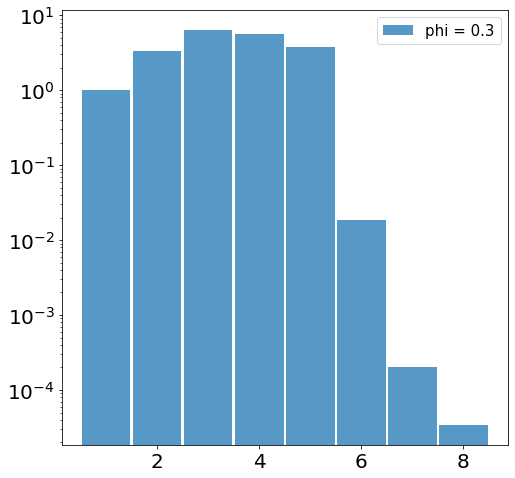

In [15]:
mask = (tsteps>=tstart)
totalhits = np.sum(hits[mask],axis=0)

bins = np.arange(0.5,maxsize+1.5,1)
fig, ax = plt.subplots(1,1,figsize=(8,8))
# ax.hist(bins[:-1],bins, weights = totalhits, rwidth=0.95)
# ax.hist(bins[:-1],bins, weights = totalhits/totalhits[0], rwidth=0.95,alpha = 0.75,color=colors[-1],label=f"phi = {phi}")
ax.hist(bins[:-1],bins, weights = totalhits/totalhits[0], rwidth=0.95,alpha = 0.75,label=f"phi = {phi}",log=True)
# ax.set_title(f"time > {tstart/1e6} million",fontsize=20)
# ax.set_xlabel("Stack Size",fontsize=20)
# ax.set_ylabel("Number of Stacks", fontsize=15)
# ax.set_ylabel("Relative Number of Stacks", fontsize=20)
ax.tick_params(labelsize=20)
ax.legend(fontsize=15)
# ax.set_ylim(0,3.5)
# ax.set_xlim(0,15)

# ax.set_ylim(0,8)
# ax.set_xlim(0,22)

## Single Frame

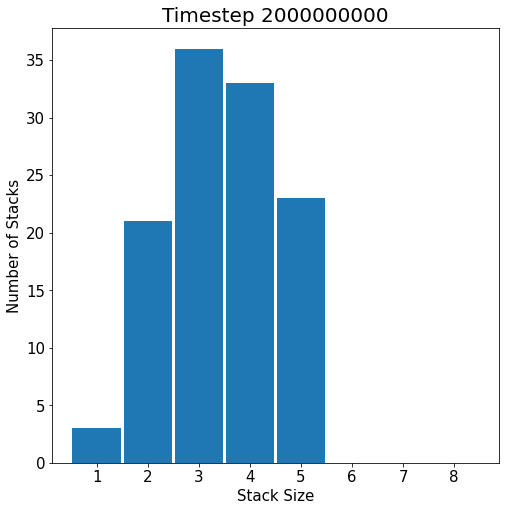

In [17]:
frame = -1
bins = np.arange(0.5,maxsize+1.5,1)
fig, ax = plt.subplots(1,1,figsize=(8,8))
ax.hist(bins[:-1],bins, weights = hits[frame], rwidth=0.95)
ax.set_title(f"Timestep {tsteps[frame]}",fontsize=20)
ax.set_xlabel("Stack Size",fontsize=15)
ax.set_ylabel("Number of Stacks", fontsize=15)
ax.tick_params(labelsize=15)

In [985]:
np.sum(hits[frame])

75

In [390]:
len(tsteps)

7700

IndexError: index 7700 is out of bounds for axis 0 with size 7700

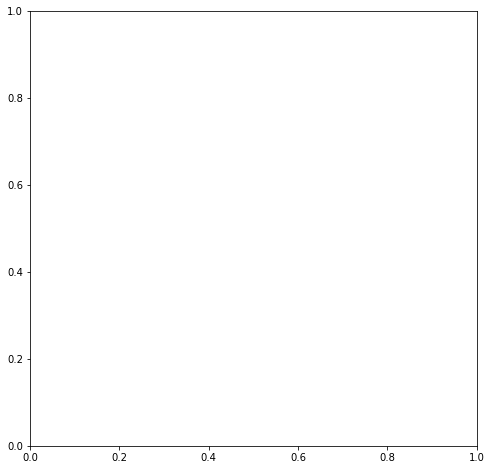

In [391]:
# save frames for distribution movie
t1 = time.time()

fstart = 0
fstop = len(tsteps)
fskip = 10
frames = np.arange(fstart,fstop+1,fskip)

parentfolder = "/Users/kyle/Movies/2026_04_01/wx-4.9-t0-0.6-Nbeads-15/sigma-0.25-kh-1000-patchy/Nmols-400/r0-6.5"
name = f"phi-{phi:0.3f}-kT-{kT:0.3f}-dist"

os.makedirs(f"{parentfolder}/{name}", exist_ok=True)

bins = np.arange(0.5,maxsize+1.5,1)
i = 0
for frame in frames:

    fig, ax = plt.subplots(1,1,figsize=(8,8))
    ax.hist(bins[:-1],bins, weights = hits[frame], rwidth=0.95)
    ax.set_title(f"Timestep {tsteps[frame]/1000000} million",fontsize=20)
    ax.set_xlabel("Stack Size",fontsize=15)
    ax.set_ylabel("Number of Stacks", fontsize=15)
    ax.tick_params(labelsize=15)
    ax.set_xlim(0,maxsize)
    ax.set_ylim(0,200)
    fig.savefig(f"{parentfolder}/{name}/image{i:05d}.png",dpi=100)
    plt.close()
    i += 1
    
t2 = time.time()
print(f"{t2-t1:0.1f}sec")

## Multiple temperatures

In [382]:
dcore = 1.0
wx = 4.9
t0 = 0.6
Nbeads = 15
r0 = "flat"
# r0 = 6.5
# r0 = 7.75
# r0 = 10
# r0 = 12
# r0 = 14
phi = 0.4
nshells = 400
sigma = 0.25
pair_ints = "1patch"
# pair_ints = "patchy"
soft_ints = 0
kh = 1000

# kT_list = [0.01,0.03,0.05,0.07]
# kT_list = [0.01,0.02,0.03,0.04,0.05]
kT_list = [0.02,0.03,0.04,0.05]
damp = 10

txtdir = "jobs/dynamics2D/distributions"


data = []
tsteps = []
hits = []
maxsize = []

for i in np.arange(len(kT_list)):
                   
    kT = kT_list[i]
    if r0 == "flat":
        txtfilename = f"wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}-nshells-{nshells}-r0-{r0}-sigma-{sigma:0.3f}-kh-{kh:0.3f}-pair_ints-{pair_ints}-soft_ints-{soft_ints}-phi-{phi:0.4f}-kT-{kT:0.4f}-damp-{damp:0.2f}.txt"
    else:
        txtfilename = f"wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}-nshells-{nshells}-r0-{r0:0.5f}-sigma-{sigma:0.3f}-kh-{kh:0.3f}-pair_ints-{pair_ints}-soft_ints-{soft_ints}-phi-{phi:0.4f}-kT-{kT:0.4f}-damp-{damp:0.2f}.txt"

    data_c = np.loadtxt(f"{PROJECT_ROOT}/{txtdir}/{txtfilename}")
    tsteps_c = np.array(data_c[:,0],int)
    hits_c = np.array(data_c[:,1:],int)
    maxsize_c = np.size(data_c[0][1:])

    data.append(data_c)
    tsteps.append(tsteps_c)
    hits.append(hits_c)
    maxsize.append(maxsize_c)

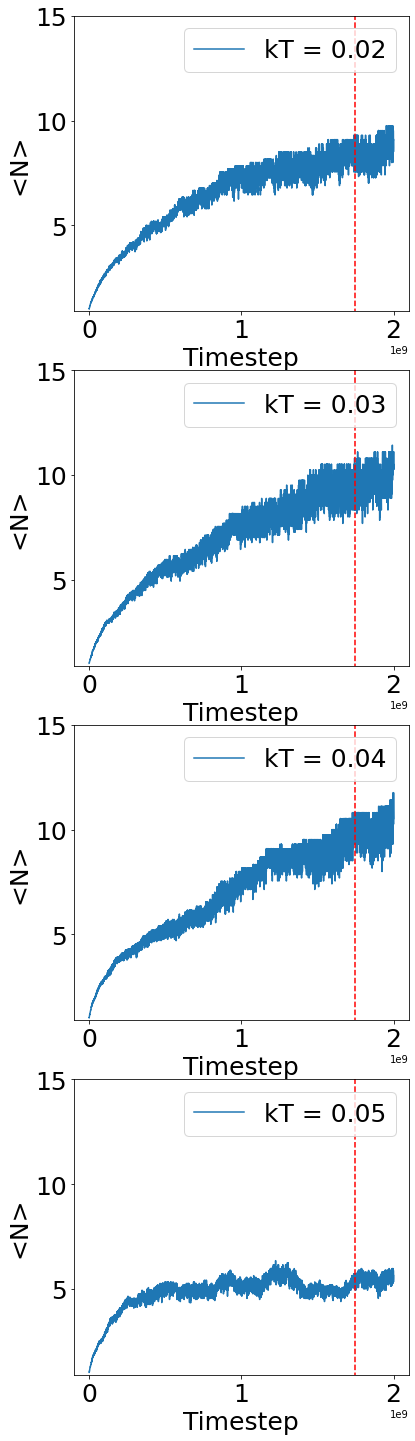

In [383]:
tstart_list = 1750 * 1e6 * np.ones(len(phi_list))
# tstart_list =  1e6 * np.array([900,800,700,350,200])

## flat
# tstart_list = 1e6 * np.array([200,200,100,100,100,100])
# tstart_list = 1e6 * np.array([400,400,400,400,350,350])
# tstart_list = 1e6 * np.array([400,400,300,300,250,150])
# tstart_list = 100 * 1e6 * np.ones(len(phi_list))


## curved
# tstart_list = 300 * 1e6 * np.ones(len(phi_list))
# tstart_list = 1e6 * np.array([400,400,350,300,250,200])
# tstart_list = 100 * 1e6 * np.ones(len(phi_list))

# tstart_list = 1e6 * np.array([400,400,400,350,200,200])

navg = []
std = []

fig, ax = plt.subplots(len(kT_list),1,figsize=(6,25))
for i in np.arange(len(kT_list)):
    num = np.sum(np.arange(1,maxsize[i]+1,1) * hits[i], axis = 1) 
    den = np.sum(hits[i],axis = 1)
    avg = num/den
    mask = (tsteps[i]>=tstart_list[i])
    navg.append(np.mean(avg[mask]))
    std.append(np.std(avg[mask]))
    ax[i].plot(tsteps[i],avg,label=f"kT = {kT_list[i]}")

    ax[i].set_xlabel("Timestep", fontsize=25)
    ax[i].set_ylabel("<N>",fontsize=25)
    ax[i].tick_params(labelsize=25)
    ax[i].vlines(tstart_list[i],ymin=0,ymax=maxsize[i],color='red',linestyle='dashed')

    ax[i].set_ylim(0.9,15)
#     ax[i].set_ylim(0.9,1.25 * avg[-1])
    ax[i].legend(fontsize=25)

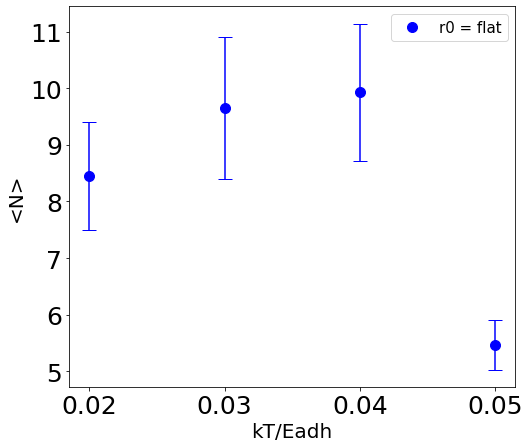

In [384]:
fig, ax = plt.subplots(1,1,figsize=(8,7))
ax.plot(np.array(kT_list),np.array(navg),"bo",markersize=10,label=f"r0 = {r0}")
ax.errorbar(np.array(kT_list),np.array(navg),yerr=2*np.array(std),ecolor="blue",fmt="none",capsize=7)
ax.set_xlabel("kT/Eadh", fontsize=20)
ax.set_ylabel("<N>",fontsize=20)
ax.tick_params(labelsize=25)
# ax.set_ylim(0.9,4.5)
# ax.set_xlim(0,0.55)

ax.legend(fontsize=15)



(0.0, 35.0)

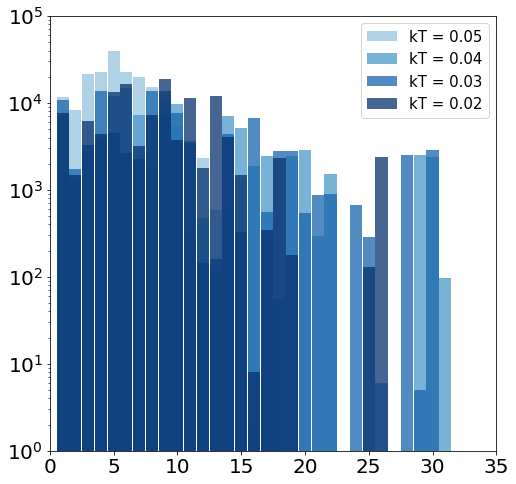

In [385]:
cmap = "Blues"
# cmap = "BuPu"
# cmap = "cool"
cmax = 0.99
cmin = 0.4
colors = []
for i in np.flip(np.arange(len(kT_list))):
    colors.append(mpl.colormaps[cmap](np.linspace(cmin,cmax,len(kT_list))[i]))

fig, ax = plt.subplots(1,1,figsize=(8,8))

counts = []
stacks = []

for i in np.flip(np.arange(len(kT_list))):
    bins = np.arange(0.5,maxsize[i]+1.5,1)
    mask = (tsteps[i]>=tstart_list[i])
    totalhits = np.sum(hits[i][mask],axis=0)
    # ax.hist(bins[:-1],bins, weights = totalhits, rwidth=0.95)
#     ax.hist(bins[:-1],bins, weights = totalhits/totalhits[0], rwidth=0.95, alpha = 0.75 , color = colors[i], label=f"phi = {phi_list[i]}")
#     ax.hist(bins[:-1],bins, weights = totalhits, rwidth=0.95, alpha = 0.75 , color = colors[i], label=f"kT = {kT_list[i]}")
    ax.hist(bins[:-1],bins, weights = totalhits, rwidth=0.95, alpha = 0.75 , color = colors[i], label=f"kT = {kT_list[i]}",log=True)

    #     ax.set_title(f"time > {tstart/1e6} million",fontsize=20)
    # ax.set_ylabel("Number of Stacks", fontsize=15)

#     ax.set_ylim(0,3.5)
#     ax.set_xlim(0,20)
    counts.append(totalhits.tolist())
    stacks.append((np.arange(len(totalhits))+1).tolist())
ax.legend(fontsize=15)

# ax.set_ylabel("Relative Number of Stacks", fontsize=20)
ax.tick_params(labelsize=20)
# ax.set_xlabel("Stack Size",fontsize=20)

ax.set_ylim(1,1e5)
ax.set_xlim(0,35)

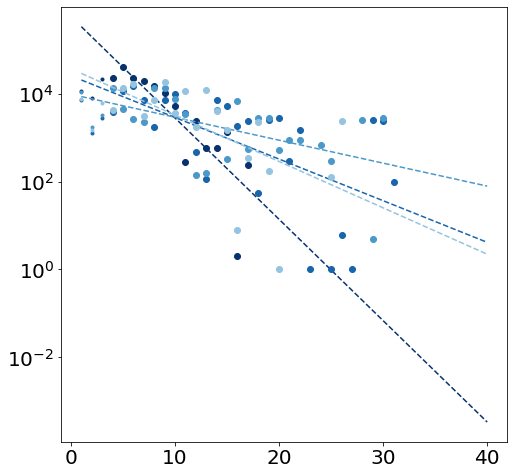

In [386]:
nmin = 4
nmax = 50
def myfunc(x,a,b):
    return x*a + b

cmap = "Blues"
# cmap = "inferno"
# cmap = "cool"
cmax = 0.99
cmin = 0.4
colors = []
for i in np.flip(np.arange(len(kT_list))):
    colors.append(mpl.colormaps[cmap](np.linspace(cmin,cmax,len(kT_list))[i]))

fig, ax = plt.subplots(1,1,figsize=(8,8))

blist = []
berrors = []
for i in range(len(kT_list)):
    countsi = counts[i]
    stacksi = stacks[i]
    mask = (np.array(stacksi)>=nmin)&(np.array(stacksi)<=nmax)
    ax.semilogy(np.array(stacksi),np.array(countsi),".",color=colors[i])
    ax.semilogy(np.array(stacksi)[mask],np.array(countsi)[mask],"o",color=colors[i])
    
    zeromask = (np.array(countsi)[mask]!=0)
    params,cov = curve_fit(myfunc,np.array(stacksi)[mask][zeromask],np.log(np.array(countsi)[mask][zeromask]))
    errs = np.sqrt(np.diag(cov))
    xfit = np.linspace(1,40,50)
    yfit = myfunc(xfit,params[0],params[1])
    ax.semilogy(xfit,np.exp(yfit),"--",color=colors[i])
    blist.append(params[1])
    berrors.append(errs[1])
# ax.legend(fontsize=15)
# ax.set_ylabel("Relative Number of Stacks", fontsize=20)
ax.tick_params(labelsize=20)
# ax.set_xlabel("Stack Size",fontsize=20)
# ax.set_ylim(-,1e5)
# ax.set_xlim(0,22)

    

In [387]:
kT_list

[0.02, 0.03, 0.04, 0.05]

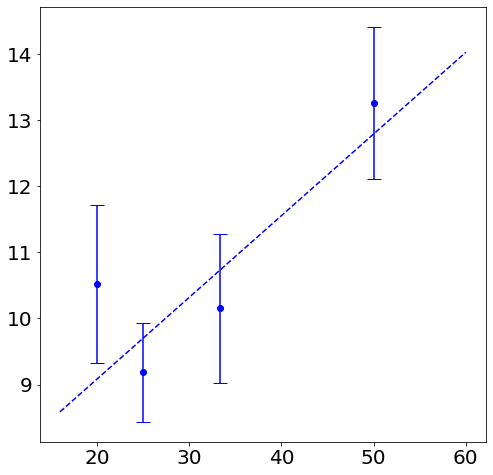

In [388]:
fig, ax = plt.subplots(1,1,figsize=(8,8))

def myfunc2(x,a,b):
    return -a/x + b

ax.plot(1/np.array(kT_list),np.array(blist),"bo")
ax.errorbar(1/np.array(kT_list),np.array(blist),yerr=np.array(berrors),ecolor="blue",fmt="none",capsize=7)

params,cov = curve_fit(myfunc,1/np.array(kT_list),np.array(blist),sigma=np.array(berrors),absolute_sigma=True)
errs = np.sqrt(np.diag(cov))
xfit = np.linspace(0.8*np.min(1/np.array(kT_list)),1.2*np.max(1/np.array(kT_list)),50)
yfit = myfunc(xfit,params[0],params[1])
ax.plot(xfit,yfit,"b--")


# ax.plot(np.array(kT_list),np.array(blist),"bo")
# ax.errorbar(np.array(kT_list),np.array(blist),yerr=np.array(berrors),ecolor="blue",fmt="none",capsize=7)

# params,cov = curve_fit(myfunc2,np.array(kT_list),np.array(blist),sigma=np.array(berrors),absolute_sigma=True)
# errs = np.sqrt(np.diag(cov))
# xfit = np.linspace(0.8*np.min(np.array(kT_list)),1.2*np.max(np.array(kT_list)),50)
# yfit = myfunc2(xfit,params[0],params[1])
# ax.plot(xfit,yfit,"b--")

# ax.legend(fontsize=15)
# ax.set_ylabel("Relative Number of Stacks", fontsize=20)
ax.tick_params(labelsize=20)
# ax.set_xlabel("Stack Size",fontsize=20)
# ax.set_ylim(-,1e5)
# ax.set_xlim(0,22)

In [391]:
params

array([0.12375034, 6.60634548])

In [392]:
np.sqrt(np.diag(cov))

array([0.04874469, 1.56635375])

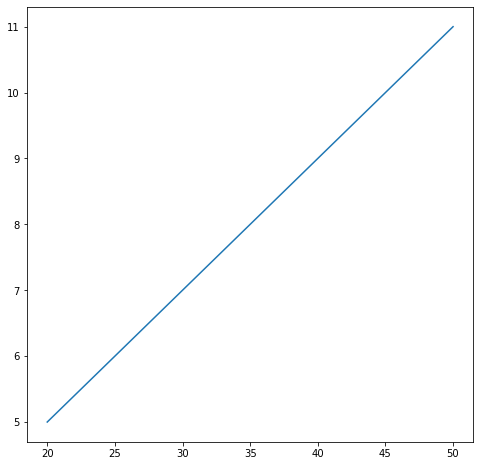

In [381]:
fig, ax = plt.subplots(1,1,figsize=(8,8))

xfit = np.linspace(0.02,0.05,40)
a = 0.2
b = 1
# ax.plot(xfit,myfunc(xfit,a,b))
ax.plot(1/xfit,myfunc(1/xfit,a,b))

## Multiple concentrations

In [116]:
dcore = 1.0
wx = 4.9
t0 = 0.6
Nbeads = 15
r0 = "flat"
# r0 = 6.5
# r0 = 7.75
# r0 = 10
# r0 = 12
# r0 = 14
phi_list = [0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5]
# phi_list = [0.05,0.1,0.15,0.2,0.25,0.3]
# phi_list = [0.05,0.15,0.25,0.35,0.45,0.5]
# phi_list = [0.05,0.1,0.2,0.3,0.4,0.5]
# phi_list=[0.3]
nshells = 400
sigma = 0.25
pair_ints = "1patch"
soft_ints = 0
kh = 1000
# r0 = 7.75
# phi_list = [0.05,0.1,0.15,0.2,0.25,0.3]

kT = 0.03
damp = 10

txtdir = "jobs/dynamics2D/distributions"


data = []
tsteps = []
hits = []
maxsize = []

for i in np.arange(len(phi_list)):
                   
    phi = phi_list[i]
    if r0 == "flat":
        txtfilename = f"wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}-nshells-{nshells}-r0-{r0}-sigma-{sigma:0.3f}-kh-{kh:0.3f}-pair_ints-{pair_ints}-soft_ints-{soft_ints}-phi-{phi:0.4f}-kT-{kT:0.4f}-damp-{damp:0.2f}.txt"
    else:
        txtfilename = f"wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}-nshells-{nshells}-r0-{r0:0.5f}-sigma-{sigma:0.3f}-kh-{kh:0.3f}-pair_ints-{pair_ints}-soft_ints-{soft_ints}-phi-{phi:0.4f}-kT-{kT:0.4f}-damp-{damp:0.2f}.txt"

    data_c = np.loadtxt(f"{PROJECT_ROOT}/{txtdir}/{txtfilename}")
    tsteps_c = np.array(data_c[:,0],int)
    hits_c = np.array(data_c[:,1:],int)
    maxsize_c = np.size(data_c[0][1:])

    data.append(data_c)
    tsteps.append(tsteps_c)
    hits.append(hits_c)
    maxsize.append(maxsize_c)

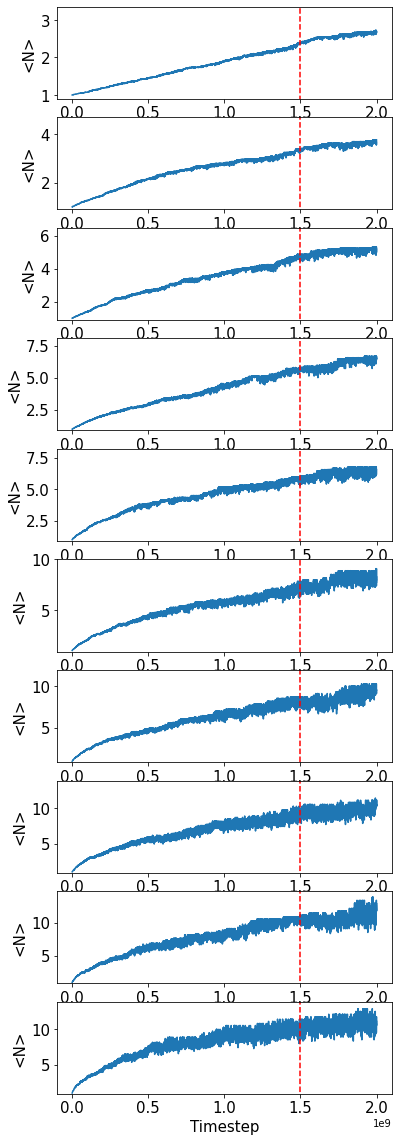

In [117]:
tstart_list = 1500 * 1e6 * np.ones(len(phi_list))

## flat
# tstart_list = 1e6 * np.array([200,200,100,100,100,100])
# tstart_list = 1e6 * np.array([400,400,400,400,350,350])
# tstart_list = 1e6 * np.array([400,400,300,300,250,150])
# tstart_list = 100 * 1e6 * np.ones(len(phi_list))


## curved
# tstart_list = 300 * 1e6 * np.ones(len(phi_list))
# tstart_list = 1e6 * np.array([400,400,350,300,250,200])
# tstart_list = 100 * 1e6 * np.ones(len(phi_list))

# tstart_list = 1e6 * np.array([400,400,400,350,200,200])


navg = []
std = []

fig, ax = plt.subplots(len(phi_list),1,figsize=(6,20))
for i in np.arange(len(phi_list)):
    num = np.sum(np.arange(1,maxsize[i]+1,1) * hits[i], axis = 1) 
    den = np.sum(hits[i],axis = 1)
    avg = num/den
    mask = (tsteps[i]>=tstart_list[i])
    navg.append(np.mean(avg[mask]))
    std.append(np.std(avg[mask]))
    ax[i].plot(tsteps[i],avg)

    ax[i].set_xlabel("Timestep", fontsize=15)
    ax[i].set_ylabel("<N>",fontsize=15)
    ax[i].tick_params(labelsize=15)
    ax[i].vlines(tstart_list[i],ymin=0,ymax=maxsize[i],color='red',linestyle='dashed')

#     ax[i].set_ylim(0.9,np.max(maxsize))
    ax[i].set_ylim(0.9,1.25 * avg[-1])

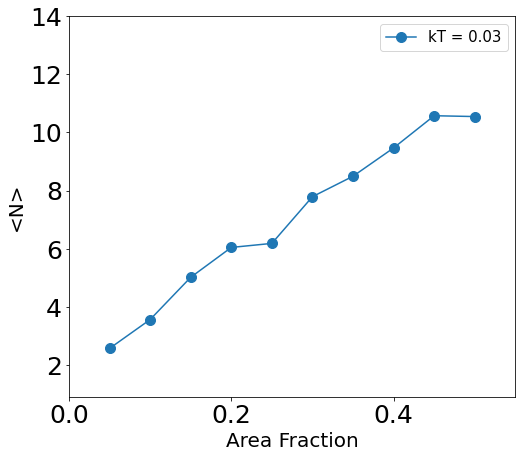

In [118]:
fig, ax = plt.subplots(1,1,figsize=(8,7))
# ax.plot(np.array(phi_list),np.array(navg),"-o",markersize=10,label=f"r0 = {r0}")
ax.plot(np.array(phi_list),np.array(navg),"-o",markersize=10,label=f"kT = {kT}")
# ax.errorbar(np.array(phi_list),np.array(navg),yerr=2*np.array(std),ecolor="black",fmt="none",capsize=7)
ax.set_xlabel("Area Fraction", fontsize=20)
ax.set_ylabel("<N>",fontsize=20)
ax.tick_params(labelsize=25)
ax.set_ylim(0.9,14)
ax.set_xlim(0,0.55)

# ax.plot(xflat,yflat,"o",markersize=10,label="flat")
# ax.plot(x14,y14,"o",markersize=10,label='r0 = 14')
# ax.plot(x12,y12,"o",markersize=10,label='r0 = 12')
# ax.plot(x10,y10,"o",markersize=10,label='r0 = 10')
# ax.plot(x7p75,y7p75,"o",markersize=10,label='r0 = 7.75')
# ax.plot(x6p5,y6p5,"o",markersize=10,label="r0 = 6.5")
# ax.legend(fontsize=15)

# ax.plot(x_kT_02,y_kT_02,"-o",markersize=10,label='kT = 0.02')
# ax.errorbar(x_kT_02,y_kT_02,yerr=yerr_kT_02,ecolor="black",fmt="none",capsize=7)
# ax.plot(x_kT_03,y_kT_03,"-o",markersize=10,label='kT = 0.03')
# ax.errorbar(x_kT_03,y_kT_03,yerr=yerr_kT_03,ecolor="black",fmt="none",capsize=7)
# ax.plot(x_kT_04,y_kT_04,"-o",markersize=10,label='kT = 0.04')
# ax.errorbar(x_kT_04,y_kT_04,yerr=yerr_kT_04,ecolor="black",fmt="none",capsize=7)
# ax.plot(x_kT_05,y_kT_05,"-o",markersize=10,label='kT = 0.05')
# ax.errorbar(x_kT_05,y_kT_05,yerr=yerr_kT_05,ecolor="black",fmt="none",capsize=7)
ax.legend(fontsize=15)

# x_kT_02 = np.array(phi_list)
# y_kT_02 = np.array(navg)
# yerr_kT_02 = np.array(std)
# x_kT_03 = np.array(phi_list)
# y_kT_03 = np.array(navg)
# yerr_kT_03 = np.array(std)
# x_kT_04 = np.array(phi_list)
# y_kT_04 = np.array(navg)
# yerr_kT_04 = np.array(std)
x_kT_05 = np.array(phi_list)
y_kT_05 = np.array(navg)
yerr_kT_05 = np.array(std)

# xflat = np.array(phi_list)
# yflat = np.array(navg)

# x14 = np.array(phi_list)
# y14 = np.array(navg)

# x12 = np.array(phi_list)
# y12 = np.array(navg)

# x10 = np.array(phi_list)
# y10 = np.array(navg)

# x9 = np.array(phi_list)
# y9 = np.array(navg)

# x7p75 = np.array(phi_list)
# y7p75 = np.array(navg)

# x6p5 = np.array(phi_list)
# y6p5 = np.array(navg)


In [936]:
np.max(maxsize)

37

(0.0, 22.0)

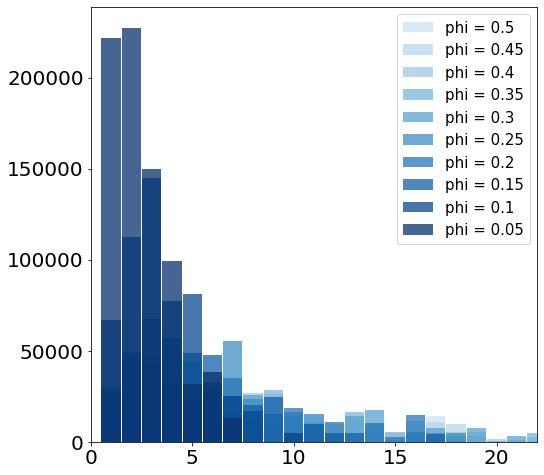

In [125]:
cmap = "Blues"
# cmap = "BuPu"
# cmap = "cool"
cmax = 0.99
cmin = 0.2
colors = []
for i in np.flip(np.arange(len(phi_list))):
    colors.append(mpl.colormaps[cmap](np.linspace(cmin,cmax,len(phi_list))[i]))

fig, ax = plt.subplots(1,1,figsize=(8,8))

for i in np.flip(np.arange(len(phi_list))):
    bins = np.arange(0.5,maxsize[i]+1.5,1)
    mask = (tsteps[i]>=tstart_list[i])
    totalhits = np.sum(hits[i][mask],axis=0)
    # ax.hist(bins[:-1],bins, weights = totalhits, rwidth=0.95)
#     ax.hist(bins[:-1],bins, weights = totalhits/totalhits[0], rwidth=0.95, alpha = 0.75 , color = colors[i], label=f"phi = {phi_list[i]}")
    ax.hist(bins[:-1],bins, weights = totalhits, rwidth=0.95, alpha = 0.75 , color = colors[i], label=f"phi = {phi_list[i]}")

    #     ax.set_title(f"time > {tstart/1e6} million",fontsize=20)
    # ax.set_ylabel("Number of Stacks", fontsize=15)

#     ax.set_ylim(0,3.5)
#     ax.set_xlim(0,20)
ax.legend(fontsize=15)

# ax.set_ylabel("Relative Number of Stacks", fontsize=20)
ax.tick_params(labelsize=20)
# ax.set_xlabel("Stack Size",fontsize=20)

# ax.set_ylim(0,8)
ax.set_xlim(0,22)

(0.0, 22.0)

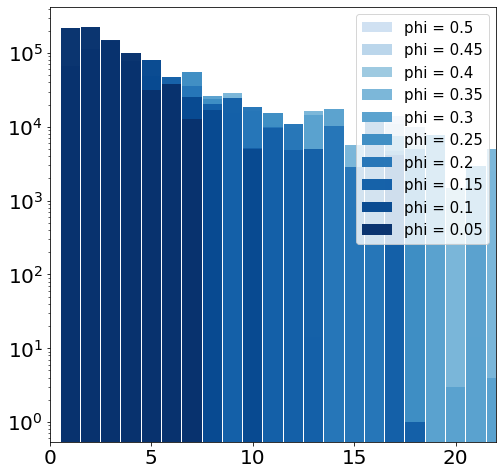

In [126]:
fig, ax = plt.subplots(1,1,figsize=(8,8))

for i in np.flip(np.arange(len(phi_list))):
    bins = np.arange(0.5,maxsize[i]+1.5,1)
    mask = (tsteps[i]>=tstart_list[i])
    totalhits = np.sum(hits[i][mask],axis=0)
    # ax.hist(bins[:-1],bins, weights = totalhits, rwidth=0.95)
#     ax.hist(bins[:-1],bins, weights = totalhits/totalhits[0], rwidth=0.95, alpha = 0.99 , color = colors[i], label=f"phi = {phi_list[i]}",log=True)
    ax.hist(bins[:-1],bins, weights = totalhits, rwidth=0.95, alpha = 0.99 , color = colors[i], label=f"phi = {phi_list[i]}",log=True)

    #     ax.set_title(f"time > {tstart/1e6} million",fontsize=20)
    # ax.set_ylabel("Number of Stacks", fontsize=15)

#     ax.set_ylim(0,3.5)
#     ax.set_xlim(0,20)
ax.legend(fontsize=15)

# ax.set_ylabel("Relative Number of Stacks", fontsize=20)
ax.tick_params(labelsize=20)
# ax.set_xlabel("Stack Size",fontsize=20)

# ax.set_ylim(0.005,1000000)
ax.set_xlim(0,22)

## Multiple curvatures

In [4]:
dcore = 1.0
wx = 4.9
t0 = 0.6
Nbeads = 15
# r0_list = [6.5,7.75,9,10,12,14,16,"flat"]
r0_list = [6.5,7.75,9,10,12,14,16]
# r0_list = [6.5,12,"flat"]
nshells = 400
sigma = 0.25
pair_ints = "1patch"
soft_ints = 0
kh = 1000
phi = 0.3
kT = 0.05
damp = 10

txtdir = "jobs/dynamics2D/distributions"


data = []
tsteps = []
hits = []
maxsize = []

for i in np.arange(len(r0_list)):
                   
    r0 = r0_list[i]
    if r0 == "flat":
        txtfilename = f"wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}-nshells-{nshells}-r0-{r0}-sigma-{sigma:0.3f}-kh-{kh:0.3f}-pair_ints-{pair_ints}-soft_ints-{soft_ints}-phi-{phi:0.4f}-kT-{kT:0.4f}-damp-{damp:0.2f}.txt"
    else:
        txtfilename = f"wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}-nshells-{nshells}-r0-{r0:0.5f}-sigma-{sigma:0.3f}-kh-{kh:0.3f}-pair_ints-{pair_ints}-soft_ints-{soft_ints}-phi-{phi:0.4f}-kT-{kT:0.4f}-damp-{damp:0.2f}.txt"

    data_c = np.loadtxt(f"{PROJECT_ROOT}/{txtdir}/{txtfilename}")
    tsteps_c = np.array(data_c[:,0],int)
    hits_c = np.array(data_c[:,1:],int)
    maxsize_c = np.size(data_c[0][1:])

    data.append(data_c)
    tsteps.append(tsteps_c)
    hits.append(hits_c)
    maxsize.append(maxsize_c)

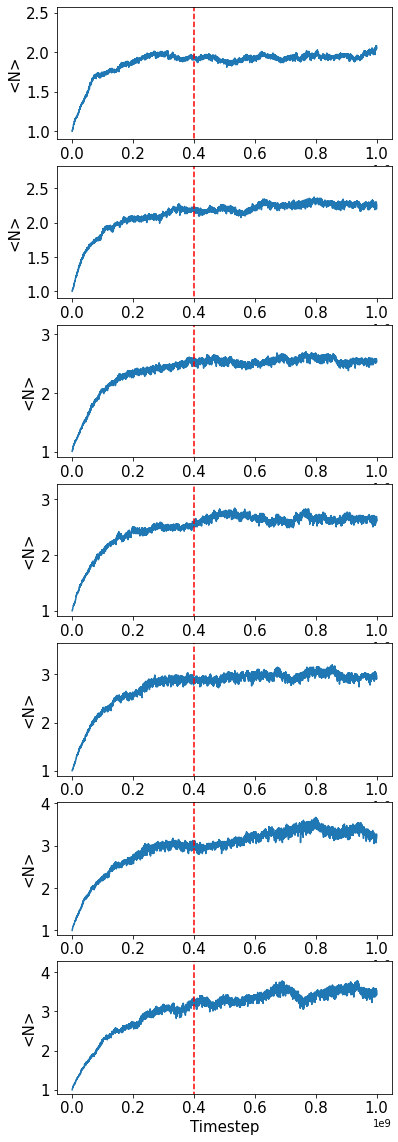

In [8]:
tstart_list = 400 * 1e6 * np.ones(len(r0_list))

navg = []
std = []

fig, ax = plt.subplots(len(r0_list),1,figsize=(6,20))
for i in np.arange(len(r0_list)):
    num = np.sum(np.arange(1,maxsize[i]+1,1) * hits[i], axis = 1) 
    den = np.sum(hits[i],axis = 1)
    avg = num/den
    mask = (tsteps[i]>=tstart_list[i])
    navg.append(np.mean(avg[mask]))
    std.append(np.std(avg[mask]))
    ax[i].plot(tsteps[i],avg)

    ax[i].set_xlabel("Timestep", fontsize=15)
    ax[i].set_ylabel("<N>",fontsize=15)
    ax[i].tick_params(labelsize=15)
    ax[i].vlines(tstart_list[i],ymin=0,ymax=maxsize[i],color='red',linestyle='dashed')

#     ax[i].set_ylim(0.9,np.max(maxsize))
    ax[i].set_ylim(0.9,1.25 * avg[-1])

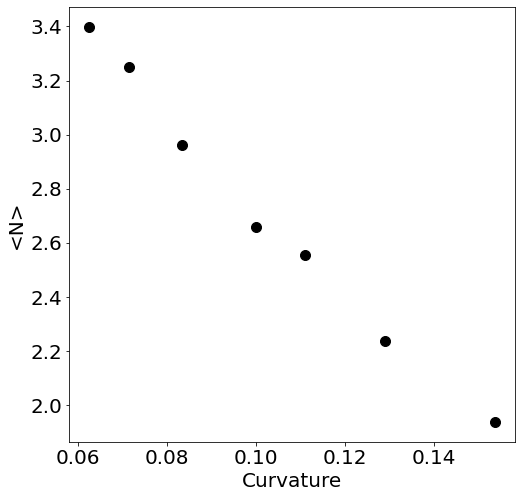

In [6]:
fig, ax = plt.subplots(1,1,figsize=(8,8))
k0_list = []
for i in np.arange(len(r0_list)):
    r0 = r0_list[i]
    if r0=="flat":
        k0 = 0
    else:
        k0=1/r0
    k0_list.append(k0)
        
ax.plot(np.array(k0_list),np.array(navg),"ko",markersize=10) 
ax.set_xlabel("Curvature", fontsize=20)
ax.set_ylabel("<N>",fontsize=20)
ax.tick_params(labelsize=20)
# ax.set_ylim(0.9,4.5)
# ax.set_xlim(0,0.5)
# ax.legend(fontsize=16)

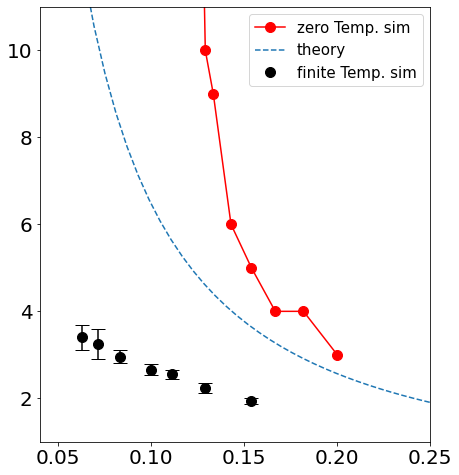

In [18]:
fig, ax = plt.subplots(1,1,figsize=(7,8))
k0_list = []
for i in np.arange(len(r0_list)):
    r0 = r0_list[i]
    if r0=="flat":
        k0 = 0
    else:
        k0=1/r0
    k0_list.append(k0)
    
xzero = 1/np.array([8,7.75,7.5,7,6.5,6,5.5,5])
yzero = np.array([19,10,9,6,5,4,4,3])
ax.plot(xzero,yzero,"ro-",markersize=10,label="zero Temp. sim")

ax.plot(np.linspace(0.01,0.3),0.3 * np.linspace(0.01,0.3)**(-4/3),"--",label="theory")
        
ax.plot(np.array(k0_list),np.array(navg),"ko",markersize=10,label="finite Temp. sim") 
ax.errorbar(np.array(k0_list),np.array(navg),yerr=2*np.array(std),ecolor="black",fmt="none",capsize=7)
# ax.set_xlabel("Curvature", fontsize=20)
# ax.set_ylabel("<N>",fontsize=20)
ax.tick_params(labelsize=20)

ax.set_xlim(0.04,0.25)
ax.set_ylim(1,11)

ax.legend(fontsize=15)

In [883]:
r0_list

[6.5, 7.75, 9, 10, 12, 14, 16, 'flat']

In [884]:
k0_list

[0.15384615384615385,
 0.12903225806451613,
 0.1111111111111111,
 0.1,
 0.08333333333333333,
 0.07142857142857142,
 0.0625,
 0]

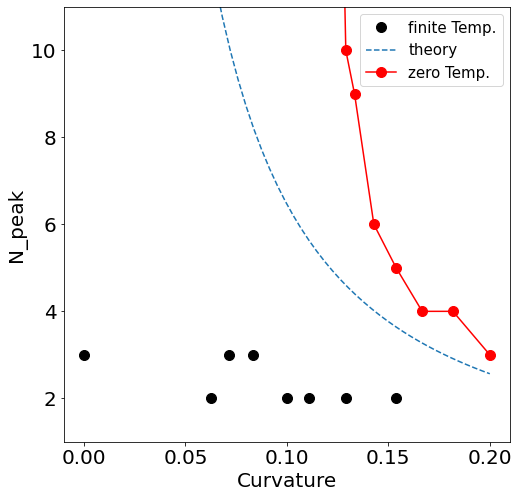

In [970]:
npeak = []
for i in np.arange(len(r0_list)):
    bins = np.arange(0.5,maxsize[i]+1.5,1)
    mask = (tsteps[i]>=tstart_list[i])
    totalhits = np.sum(hits[i][mask],axis=0)
#     print((totalhits/totalhits[0]))
    peak = np.arange(1,maxsize[i])[np.argmax(totalhits)]
    npeak.append(peak)
    
        
fig, ax = plt.subplots(1,1,figsize=(8,8))
ax.plot(np.array(k0_list),np.array(npeak),"ko",markersize=10,label="finite Temp.")
    
ax.set_xlabel("Curvature", fontsize=20)
ax.set_ylabel("N_peak",fontsize=20)
ax.tick_params(labelsize=20)
ax.plot(np.linspace(0.01,0.2),0.3 * np.linspace(0.01,0.2)**(-4/3),"--",label="theory")
ax.set_ylim(1,11)

xzero = 1/np.array([8,7.75,7.5,7,6.5,6,5.5,5])
yzero = np.array([19,10,9,6,5,4,4,3])

ax.plot(xzero,yzero,"ro-",markersize=10,label="zero Temp.")
ax.legend(fontsize=15)

In [855]:
np.argmax(totalhits)

1

In [858]:
np.arange(1,maxsize[-1])[np.argmax(totalhits)]

2

# Local

In [331]:
### read dump file
simdir = f"/Users/kyle/Documents/Code/cgshells"
dumpname = f"patchy-r0-6.5-phi-0.5-kT-0.03-trajectory5.dump.gz"
readall = True

result = ReadSim(simdir)
result.read_dump(dumpname=dumpname,readall=readall)

In [332]:
frame = 1281
print(f"timestep = {result.tsteps[frame]}")
nmols = np.max(result.dump_mol[frame])
molid = []
radii = []
for i in np.arange(1,nmols+1,1):
    mol = i
    rfit = molradius(result,frame,mol)
    molid.append(mol)
    radii.append(rfit)
    

timestep = 599000000


In [323]:
result.natoms

12000

In [321]:

np.argmin((result.tsteps-599000000)**2)

1281

In [324]:
contents = f"""ITEM: TIMESTEP
{result.tsteps[frame]}
ITEM: NUMBER OF ATOMS
{result.natoms}
ITEM: ATOMS id mol x y z shellCurv\n"""
for i in np.arange(len(result.dump_id[frame])):
    aid = result.dump_id[frame][i]
    mol = result.dump_mol[frame][i]
    mask = (np.array(molid)==mol)
    r = np.array(radii)[mask][0]
    x = result.dump_x[frame][i]
    y = result.dump_y[frame][i]
    z = result.dump_z[frame][i]

    contents += f"{int(aid)} {int(mol)} {x:0.3f} {y:0.3f} {z:0.3f} {1/r:0.10f}\n"
    
# i = 400
# aid = result.dump_id[frame][i]
# mol = result.dump_mol[frame][i]
# mask = (np.array(molid)==mol)
# r = np.array(radii)[mask][0]

# contents += f"{int(aid)} {int(mol)} {1/r}\n"

In [326]:
contents

'ITEM: TIMESTEP\n599000000\nITEM: NUMBER OF ATOMS\n12000\nITEM: ATOMS id mol x y z shellCurv\n1 1 -42.563 -29.099 -0.002 0.0122517494\n2 1 -42.892 -29.091 -0.001 0.0122517494\n3 1 -43.228 -29.058 -0.002 0.0122517494\n4 1 43.351 -29.001 -0.001 0.0122517494\n5 1 43.018 -28.943 0.004 0.0122517494\n6 1 42.693 -28.856 0.000 0.0122517494\n7 1 42.379 -28.756 -0.002 0.0122517494\n8 1 42.059 -28.637 0.000 0.0122517494\n9 1 41.754 -28.503 -0.003 0.0122517494\n10 1 41.458 -28.375 0.000 0.0122517494\n11 1 41.159 -28.220 0.002 0.0122517494\n12 1 40.870 -28.067 0.006 0.0122517494\n13 1 40.593 -27.881 -0.002 0.0122517494\n14 1 40.318 -27.683 0.003 0.0122517494\n15 1 40.052 -27.487 -0.001 0.0122517494\n16 1 -42.550 -29.709 -0.002 0.0122517494\n17 1 -42.921 -29.675 -0.000 0.0122517494\n18 1 -43.298 -29.645 -0.001 0.0122517494\n19 1 43.244 -29.603 -0.000 0.0122517494\n20 1 42.890 -29.528 -0.001 0.0122517494\n21 1 42.538 -29.442 0.002 0.0122517494\n22 1 42.180 -29.334 -0.004 0.0122517494\n23 1 41.843 -29

In [325]:
fname = f"patchy-r0-6.5-phi-0.5-kT-0.03-trajectory5-extras.dump.gz"
with gzip.open(f"{PROJECT_ROOT}/{fname}", "wt") as f:
    f.write(contents)

In [37]:
result.dumps[frame][0]

array([ 1.00000e+00,  1.00000e+00,  1.00000e+00,  3.55159e+01,
       -4.80203e+01,  1.93003e-03])

(array([ 23.,   4.,   0.,   0.,   8.,  52., 108.,  72.,  92.,  41.]),
 array([3.14978894e-05, 2.04975698e-02, 4.09636417e-02, 6.14297136e-02,
        8.18957856e-02, 1.02361857e-01, 1.22827929e-01, 1.43294001e-01,
        1.63760073e-01, 1.84226145e-01, 2.04692217e-01]),
 <BarContainer object of 10 artists>)

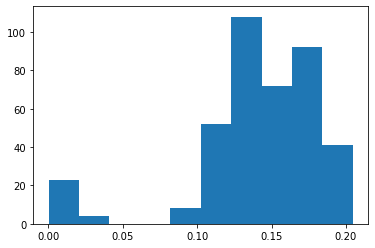

In [32]:
plt.hist(1/np.array(radii))
# plt.hist(np.array(radii))

In [33]:
1/6.5

0.15384615384615385

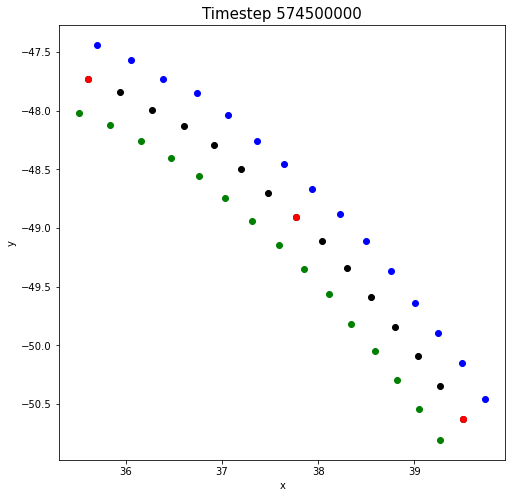

In [25]:
frame = 745
mol = 1

nshells = np.max(result.dump_mol)    # number of molecules in simulation
molatoms = result.natoms/nshells    # number of atoms per molecule

# aid1 = molatoms/4 + (mol - 1)*molatoms
# aid2 = 3*molatoms/4 + (mol - 1)*molatoms
fig, ax = plt.subplots(1,1,figsize=(8,8))
# ax.plot(result.dump_x[frame],result.dump_y[frame],"k.")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Timestep {}".format(result.tsteps[frame]),fontsize=15)

mask = (result.dump_mol[frame]==mol)
ax.plot(result.dump_x[frame][mask],result.dump_y[frame][mask],"r.")

idmin = np.min(result.dump_id[frame][mask])
minmask = (result.dump_id[frame][mask] == idmin)
idmax = np.max(result.dump_id[frame][mask])
maxmask = (result.dump_id[frame][mask] == idmax)
idmid = int((idmax-idmin)/2 + idmin)
midmask = (result.dump_id[frame][mask] == idmid)
botmask = (result.dump_id[frame][mask]>=idmin) * (result.dump_id[frame][mask]<=idmid)
topmask = (result.dump_id[frame][mask]>idmid) * (result.dump_id[frame][mask]<=idmax)

midx = result.dump_x[frame][mask][botmask] + (result.dump_x[frame][mask][topmask] - result.dump_x[frame][mask][botmask])/2
midy = result.dump_y[frame][mask][botmask] + (result.dump_y[frame][mask][topmask] - result.dump_y[frame][mask][botmask])/2
midx_left = midx[0]
midx_right = midx[-1]
midy_left = midy[0]
midy_right = midy[-1]
idcenter = int(len(midx)/2)
midx_center = midx[idcenter]
midy_center = midy[idcenter]



# ax.plot(result.dump_x[frame][mask][minmask],result.dump_y[frame][mask][minmask],"go")
# ax.plot(result.dump_x[frame][mask][maxmask],result.dump_y[frame][mask][maxmask],"go")
# ax.plot(result.dump_x[frame][mask][midmask],result.dump_y[frame][mask][midmask],"go")
ax.plot(result.dump_x[frame][mask][botmask],result.dump_y[frame][mask][botmask],"go")
ax.plot(result.dump_x[frame][mask][topmask],result.dump_y[frame][mask][topmask],"bo")
ax.plot(midx,midy,"ko")
ax.plot(midx_left,midy_left,"ro")
ax.plot(midx_right,midy_right,"ro")
ax.plot(midx_center,midy_center,"ro")


# a1mask = (result.dump_id[frame][mask]==aid1)
# a2mask = (result.dump_id[frame][mask]==aid2)
# ax.plot(result.dump_x[frame][mask][a1mask],result.dump_y[frame][mask][a1mask],"bo")
# ax.plot(result.dump_x[frame][mask][a2mask],result.dump_y[frame][mask][a2mask],"go")

In [13]:
ReadSim.fitcircle(midx_left,midy_left,midx_center,midy_center,midx_right,midy_right)

8.233409369883109

In [1162]:
(result.dump_id[frame][mask]>=idmin) * (result.dump_id[frame][mask]<=idmid)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [1150]:
odds = (result.dump_id[frame][mask] % 2 == 1)
evens = (result.dump_id[frame][mask] % 2 == 0)
result.dump_id[frame][mask]

array([2731., 2732., 2733., 2734., 2735., 2736., 2737., 2738., 2739.,
       2740., 2741., 2742., 2743., 2744., 2745., 2746., 2747., 2748.,
       2749., 2750., 2751., 2752., 2753., 2754., 2755., 2756., 2757.,
       2758., 2759., 2760.])

In [1135]:
rcut = 1.9
aggs = find_stacks(result,frame,rcut)

amax = 0
amax_i = 0
for i in np.arange(len(aggs)):
    if len(aggs[i])>amax:
        amax = len(aggs[i])
        amax_i = i
print(f"max stack size = {amax}")
print(f"index = {amax_i}")
print(f"molids = {(np.array(aggs[amax_i]) + 1).tolist()}")

max stack size = 4
index = 53
molids = [61, 113, 99, 92]


max stack size = 4
index = 53
molids = [60, 112, 98, 91]


In [1123]:
result.dump_mol[frame][:20]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [493]:
### read dump file
simdir = f"{PROJECT_ROOT}/reference/readsimfiles" 
dumpname = "complete.dump.gz"
readall = True

result = ReadSim(simdir)
result.read_dump(dumpname=dumpname,readall=readall)

In [432]:
PROJECT_ROOT

'/Users/kyle/Documents/Code/cgshells'

In [496]:
### read dump file
wx = 28
phi = 0.25
kT = 0.09
simdir = f"/Users/kyle/Documents/Code/2DCurvamers_v2/Trajectories/Nbeads-60-Nmols-50/wx-{wx:0.2f}-sigma-1.000-kh-1000.00-r0-flat" 
dumpname = f"phi-{phi:0.3f}-kT-{kT:0.3f}-R1.dump.gz"
readall = True

result = ReadSim(simdir)
result.read_dump(dumpname=dumpname,readall=readall)


In [434]:
result.nframes

2001

In [3]:
nshells = np.max(result.dump_mol)    # number of molecules in simulation
molatoms = result.natoms/nshells    # number of atoms per molecule


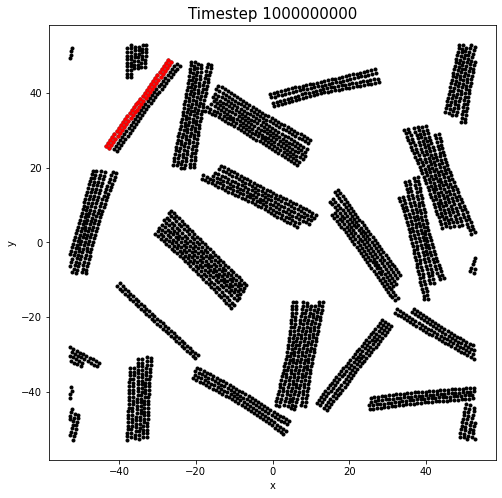

In [435]:
frame = -1
mol = 20
aid1 = molatoms/4 + (mol - 1)*molatoms
aid2 = 3*molatoms/4 + (mol - 1)*molatoms
fig, ax = plt.subplots(1,1,figsize=(8,8))
ax.plot(result.dump_x[frame],result.dump_y[frame],"k.")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Timestep {}".format(result.tsteps[frame]),fontsize=15)

mask = (result.dump_mol[frame]==mol)
ax.plot(result.dump_x[frame][mask],result.dump_y[frame][mask],"r.")
a1mask = (result.dump_id[frame][mask]==aid1)
a2mask = (result.dump_id[frame][mask]==aid2)
ax.plot(result.dump_x[frame][mask][a1mask],result.dump_y[frame][mask][a1mask],"bo")
ax.plot(result.dump_x[frame][mask][a2mask],result.dump_y[frame][mask][a2mask],"go")

In [109]:
rm,vm = find_midlayer_pt(result,frame)

In [108]:
rm[:,0]

array([ -63.5147  ,   49.31625 ,   29.2954  ,  -88.234   ,  113.8225  ,
        -43.58905 ,  -73.14015 ,   56.9455  ,  -12.0154  ,   -4.34303 ,
        -81.43475 ,   86.5347  ,  -59.9223  ,  113.749   ,   33.47855 ,
         77.1566  , -100.987   ,   19.9005  ,  114.9405  ,   31.33195 ,
         20.7869  ,   -4.16114 ,   39.67835 ,  -13.4759  , -100.0823  ,
         67.00785 ,  -12.73955 ,  -83.0859  ,  -90.168   ,   38.06285 ,
         70.6976  ,  -44.31715 ,   70.09755 ,   -6.680615,  -17.6719  ,
        -12.81955 ,   65.7137  ,  -44.50485 ,  113.074   ,  109.4795  ,
         75.4031  ,  -11.17335 ,  -75.05735 ,  -17.1746  ,  -13.6389  ,
        113.439   ,  -46.68705 ,   50.8987  ,  -64.1997  ,   35.31195 ])

In [43]:
nshells = np.max(result.dump_mol)    # number of molecules in simulation
molatoms = result.natoms/nshells    # number of atoms per molecule

ri = []
vi = []
for i in np.arange(nshells):
    mol = i+1
    aid1 = molatoms/4 + (mol - 1)*molatoms    # id of middle-most atom in bottom layer 
    aid2 = 3*molatoms/4 + (mol - 1)*molatoms    # id of middle-most atom in bottom layer 
    mask = (result.dump_mol[frame]==mol)    # molecule mask
    a1mask = (result.dump_id[frame][mask]==aid1)
    a2mask = (result.dump_id[frame][mask]==aid2)
    r1 = np.array([result.dump_x[frame][mask][a1mask][0], # position of bottom atom
                   result.dump_y[frame][mask][a1mask][0],
                   result.dump_z[frame][mask][a1mask][0]])
    r2 = np.array([result.dump_x[frame][mask][a2mask][0],    # position of top atom
           result.dump_y[frame][mask][a2mask][0],
           result.dump_z[frame][mask][a2mask][0]])
    zdist = np.sqrt(np.sum((r2-r1)**2))
    vmol = (r2-r1)/zdist    # molecule orientation vector
    rmol = r1 + 0.5*zdist*vmol    # position of molecule center
    ri.append(rmol.tolist())
    vi.append(vmol.tolist())

In [44]:
r1

array([ 35.8122, -47.9107,   0.    ])

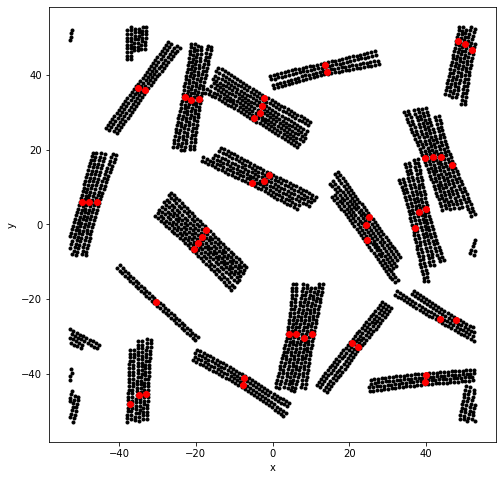

In [436]:
frame = -1

rm, vm = find_midlayer_pt(result,frame)

fig, ax = plt.subplots(1,1,figsize=(8,8))
ax.plot(result.dump_x[frame],result.dump_y[frame],"k.")
ax.set_xlabel("x")
ax.set_ylabel("y")
# ax.set_title("Timestep {}".format(result.tsteps[frame]),fontsize=15)

ax.plot(rm[:,0],rm[:,1],"ro")


In [383]:
rshift

118.32159566199232

In [2]:
phi = 0.25
kT = 0.09

# simdir = f"/Users/kyle/Documents/Code/2DCurvamers_v2/Trajectories/Nbeads-60-Nmols-50/sigma-1.000-kh-265.00-r0-flat" 
# dumpname = f"phi-{phi:0.3f}-kT-{kT:0.3f}-R1.dump.gz"
simdir = f"/Users/kyle/Documents/Code/cgshells" 
dumpname = "wx-18.67-r0-flat-kh-rigid-phi-0.4-kT-0.08-last.dump.gz" #f"phi-0.4-kT-0.09-last.dump.gz"
# dumpname = f"trajectory1.dump.gz"
readall = True

result = ReadSim(simdir)
result.read_dump(dumpname=dumpname,readall=readall)

In [2]:
simdir = f"/Users/kyle/Documents/Code/cgshells/damp-10.000" 
dumpname = f"trajectory1.dump.gz"
readall = True

result = ReadSim(simdir)
result.read_dump(dumpname=dumpname,readall=readall)

In [376]:
np.argmin((result.tsteps - 145700000)**2)

0

In [375]:
result.tsteps[1461]%200000

IndexError: index 1461 is out of bounds for axis 0 with size 1291

In [10]:
frame = 1457#-1
rcut = 1.9
images = "True"    # show periodic images
# aggs = find_stacks(result,frame,rcut)

nshells = np.max(result.dump_mol)
box_x = result.xhi - result.xlo
box_y = result.yhi - result.ylo
rshift = 0.5*np.array(box_x,box_y)    # shift points so that box starts at (0,0)
rm, vm = find_midlayer_pt(result,frame)
tree = KDTree(rm+rshift,boxsize=2*rshift)

# done = []
# aggs = []
# for i in np.arange(nshells,dtype=int):    # Note: rm[0] is mol = 1 in LAMMPS
#     if i not in done:
#         done.append(i)
#         agg_i = [i]    # indeces of molecules in same aggregate as mol i (i = index, not molid)
#         ni_indeces = tree.query_ball_point((rm+rshift)[i],rcut)
#         for j in ni_indeces:
#             if (j != i)and(np.sum(vm[i]*vm[j])>0):                          
#                 agg_i.append(j)
#                 done.append(j)
#                 nj_indeces = tree.query_ball_point((rm+rshift)[j],rcut)
#                 for k in nj_indeces:
#                     if (k not in ni_indeces)and(np.sum(vm[k]*vm[j])>0):
#                         ni_indeces.append(k)
#         aggs.append(agg_i)

ValueError: Some input data are greater than the size of the periodic box.

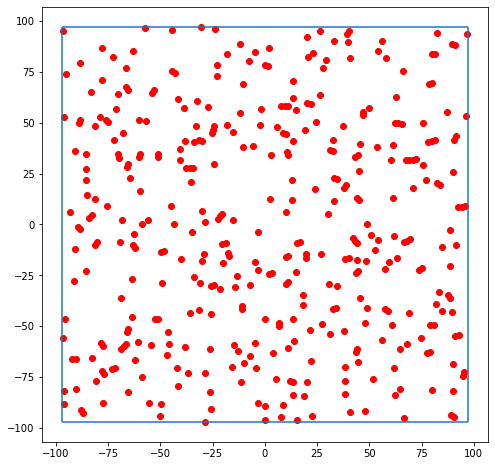

In [26]:
fig, ax = plt.subplots(1,1,figsize = (8,8))
ax.plot(rm[:,0],rm[:,1],"ro")
ax.vlines(-box_x/2,ymin=-box_y/2,ymax=box_y/2)
ax.vlines(box_x/2,ymin=-box_y/2,ymax=box_y/2)
ax.hlines(-box_y/2,xmin=-box_x/2,xmax=box_x/2)
ax.hlines(box_y/2,xmin=-box_x/2,xmax=box_x/2)

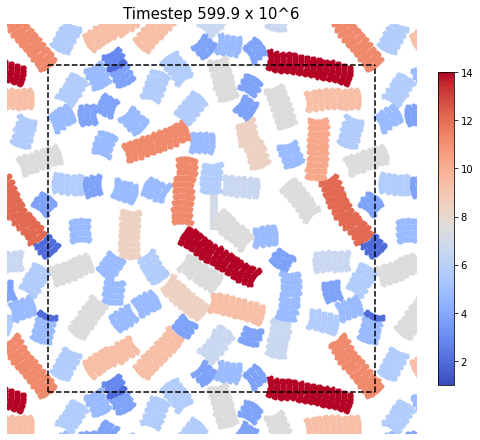

In [378]:
# frame = 1457#-1
rcut = 1.9
images = "True"    # show periodic images
aggs = find_stacks(result,frame,rcut)
sizes = []
for s in aggs:
    sizes.append(len(s))
sizes = np.array(sizes)
maxsize = np.max(sizes)
# maxsize = 5
rshift = np.array([0.5*(result.xhi-result.xlo),0.5*(result.yhi-result.ylo)])

# colors = ["b","r","g","c","m","y"]    # loop over colors for each stack
cmap = mpl.colormaps["coolwarm"]    # color by size
dotstyle = "."

fig, ax = plt.subplots(1,1,figsize=(8,8))
# ax.plot(result.dump_x[frame],result.dump_y[frame],f"k{dotstyle}")

# color bar
im = 0.5*(maxsize-0)*np.ones(2*maxsize).reshape(maxsize,2)
plt.imshow(im,cmap = cmap,vmin=1,vmax=maxsize)
plt.colorbar(location="right",fraction=0.035)

for s in range(len(aggs)):
    stack = aggs[s]
    for i in range(len(stack)):
        mask = ( result.dump_mol[frame]==(stack[i]+1) )
#         ax.plot(result.dump_x[frame][mask],result.dump_y[frame][mask],f"{colors[s%len(colors)]}.")    
        ax.plot(result.dump_x[frame][mask],result.dump_y[frame][mask],f"{dotstyle}",color=cmap(len(stack)/maxsize))    # color by size
        
        # periodic images
        if images == "True":
            # top, bot, right, left images
            ax.plot(result.dump_x[frame][mask]+2*rshift[0],result.dump_y[frame][mask],f"{dotstyle}",color=cmap(len(stack)/maxsize))
            ax.plot(result.dump_x[frame][mask]-2*rshift[0],result.dump_y[frame][mask],f"{dotstyle}",color=cmap(len(stack)/maxsize))
            ax.plot(result.dump_x[frame][mask],result.dump_y[frame][mask]+2*rshift[1],f"{dotstyle}",color=cmap(len(stack)/maxsize))
            ax.plot(result.dump_x[frame][mask],result.dump_y[frame][mask]-2*rshift[1],f"{dotstyle}",color=cmap(len(stack)/maxsize))
            # corners
            ax.plot(result.dump_x[frame][mask]+2*rshift[0],result.dump_y[frame][mask]+2*rshift[1],f"{dotstyle}",color=cmap(len(stack)/maxsize))
            ax.plot(result.dump_x[frame][mask]-2*rshift[0],result.dump_y[frame][mask]+2*rshift[1],f"{dotstyle}",color=cmap(len(stack)/maxsize))
            ax.plot(result.dump_x[frame][mask]+2*rshift[0],result.dump_y[frame][mask]-2*rshift[1],f"{dotstyle}",color=cmap(len(stack)/maxsize))
            ax.plot(result.dump_x[frame][mask]-2*rshift[0],result.dump_y[frame][mask]-2*rshift[1],f"{dotstyle}",color=cmap(len(stack)/maxsize))
            
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Timestep {} x 10^6".format(result.tsteps[frame]/1000000),fontsize=15)

if images == "True":
    # show sim box boundary for periodic images
    ax.axis("off")
    ax.vlines(np.array([result.xlo,result.xhi]),result.ylo,result.yhi,linestyle="dashed",color="black")
    ax.hlines(np.array([result.ylo,result.yhi]),result.xlo,result.xhi,linestyle="dashed",color="black")
    impct = 0.25    # percent of periodic images to show
    ax.set_xlim((1+impct)*result.xlo,(1+impct)*result.xhi)
    ax.set_ylim((1+impct)*result.ylo,(1+impct)*result.yhi)




In [457]:
result.t

array([         0,     500000,    1000000, ...,  999000000,  999500000,
       1000000000])

In [10]:
maxsize

17

In [559]:
np.arange(0.5,20+1.5,1)

array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
       11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5])

Text(0, 0.5, 'Number of Stacks')

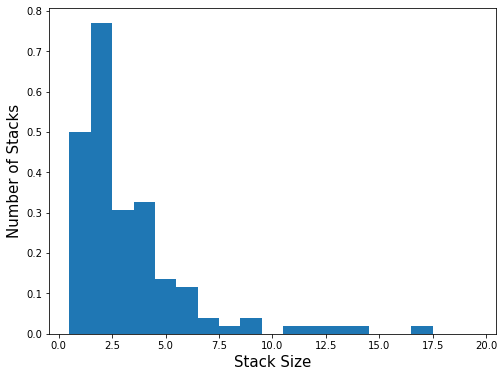

In [4]:
sizes = []
for stack in aggs:
    sizes.append(len(stack))
sizes = np.array(sizes)

# plt.hist(sizes,bins=np.arange(0.5,20+0.5,1),weights=(1/52)*np.ones(len(sizes)))

fig, ax = plt.subplots(1,1,figsize=(8,6))
ax.hist(sizes,bins=np.arange(0.5,20+0.5,1),weights=(1/52)*np.ones(len(sizes)))
ax.set_xlabel("Stack Size",fontsize = 15)
ax.set_ylabel("Number of Stacks",fontsize = 15)

In [7]:
rcut = 5
lastf = 500
sizes_list = []
maxsize = 0

if lastf > result.nframes:
    f1 = 0
else:
    f1 = lastf
    
for f in np.arange(result.nframes)[-f1:]:
    aggs = find_stacks(result,f,rcut)
    sizes = []
    for s in aggs:
        sizes.append(len(s))
    sizes_list.append(sizes)
    if np.max(sizes)>maxsize:
        maxsize = np.max(sizes)
        
sizes = []
for i in sizes_list:
    for j in i:
        sizes.append(j)
sizes = np.array(sizes)
maxsize

17

In [8]:
result.nframes

531

In [609]:
(np.arange(result.nframes)+1)[-f1:]

array([81])

(array([4.88906977e+01, 5.79372093e+01, 2.03883721e+01, 1.52674419e+01,
        5.70465116e+00, 3.59069767e+00, 5.80930233e+00, 8.20930233e-01,
        1.70465116e+00, 1.62790698e-02, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.39534884e-02]),
 array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5]),
 <BarContainer object of 14 artists>)

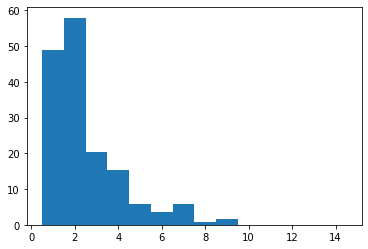

In [13]:
plt.hist(sizes,bins=np.arange(0.5,maxsize+1.5,1),weights=(1/len((np.arange(result.nframes)+1)[-f1:]))*np.ones(len(sizes)))


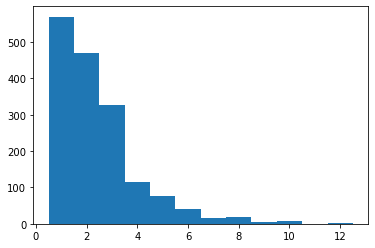

In [619]:
a = plt.hist(sizes,bins=np.arange(0.5,maxsize+1.5,1))


In [620]:
a[0]

array([570., 471., 328., 116.,  77.,  40.,  15.,  19.,   6.,   8.,   0.,
         2.])

Text(0, 0.5, 'Avg. Number of Stacks')

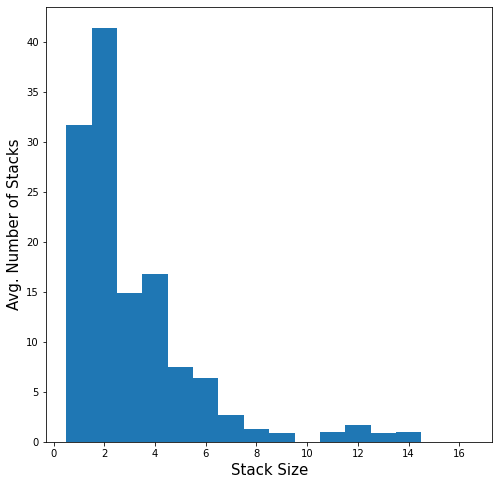

In [11]:
fig, ax = plt.subplots(1,1,figsize=(8,8))
ax.hist(sizes,bins=np.arange(0.5,maxsize+0.5,1),weights=(1/len((np.arange(result.nframes)+1)[-f1:]))*np.ones(len(sizes)))
ax.set_xlabel("Stack Size",fontsize = 15)
ax.set_ylabel("Avg. Number of Stacks",fontsize = 15)

/var/folders/w3/c7hvmnqd3vl040rr0y2bfmv00000gn/T/ipykernel_39935/1030199504.py:20: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  plt.hist(np.array(sizes_list).flatten(),bins=[0.5,1.5,2.5,3.5,4.5,6.5,7.5,8.5,9.5,10.5])


(array([[36., 42., 15., ...,  2.,  1.,  0.],
        [39., 40., 15., ...,  1.,  1.,  0.],
        [38., 41., 16., ...,  2.,  1.,  0.],
        ...,
        [30., 43., 17., ...,  1.,  1.,  0.],
        [33., 43., 16., ...,  0.,  0.,  0.],
        [31., 43., 17., ...,  1.,  1.,  0.]]),
 array([ 0.5,  1.5,  2.5,  3.5,  4.5,  6.5,  7.5,  8.5,  9.5, 10.5]),
 <a list of 500 BarContainer objects>)

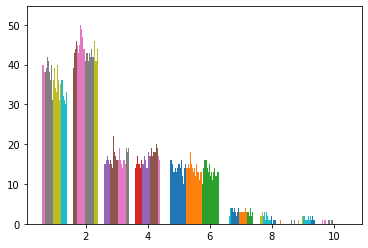

In [5]:
rcut = 3
lastf = 500
sizes_list = []
maxsize = 0

if lastf > result.nframes:
    f1 = 0
else:
    f1 = lastf
    
for f in np.arange(result.nframes)[-f1:]:
    aggs = find_stacks(result,f,rcut)
    sizes = []
    for s in aggs:
        sizes.append(len(s))
    sizes_list.append(sizes)
    if np.max(sizes)>maxsize:
        maxsize = np.max(sizes)

plt.hist(np.array(sizes_list).flatten(),bins=[0.5,1.5,2.5,3.5,4.5,6.5,7.5,8.5,9.5,10.5])

(array([2000., 1500., 3000., 2000.,  500.,    0.,    0.,    0.,    0.]),
 array([ 0.5,  1.5,  2.5,  3.5,  4.5,  6.5,  7.5,  8.5,  9.5, 10.5]),
 <BarContainer object of 9 artists>)

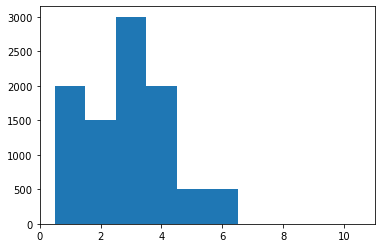

In [475]:
rcut = 5
lastf = 500
sizes_list = []
maxsize = 0
for f in np.arange(result.nframes)[-lastf:]:
    aggs = find_stacks(result,frame,rcut)
    sizes = []
    for s in aggs:
        sizes.append(len(s))
    sizes_list.append(sizes)
    if np.max(sizes)>maxsize:
        maxsize = np.max(sizes)

plt.hist(np.array(sizes_list).flatten(),bins=[0.5,1.5,2.5,3.5,4.5,6.5,7.5,8.5,9.5,10.5])

In [499]:
(result.xhi-result.xlo)/wx

3.779644730092272

In [471]:
np.array(sizes_list).flatten()

array([3, 3, 4, ..., 1, 1, 3])

In [497]:
maxsize

5

In [312]:
n = 0
for i in aggs:
    n+= len(i)
n==nshells

True

In [508]:
a = 0
try:
#     if meta['logistics']['stopcriterion'] == 'walltime limit reached':
    if b == 1:
#         return True
        x = True
    else:
#         return False
        x = False
except:
#     return True
    x = True
    
x

True

In [515]:

(-0.95823128-(-0.95823127))/-0.95823128

1.0435893984015626e-08

In [528]:
dcore = 1
t0 = 1
t = t0 + dcore
wx = 18.67
cmax = 0.43
n = 100*wx*cmax/t
n

401.40500000000003

In [529]:
n*2*20

16056.2

In [533]:
10 * 1000000 / 50000


200.0

In [535]:
8*4

32

In [653]:
sizedir = "jobs/dynamics2D/wx-18.67-t0-1-Nbeads-20/Nmols-400/sizes"
tfile = "r0-flat-sigma-1.00000-kh-5000.00000-phi-0.40000-kT-0.06000.txt"
data = np.loadtxt(f"{PROJECT_ROOT}/{sizedir}/{tfile}")
maxsize = data[0][-1]
nframes = len(data)-1

In [642]:
maxsize = data[0][-1]
nframes = len(data)-1

In [626]:
nframes = len(data)-1

253

In [632]:
"1,"*int(data[1][0])

'1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,'

In [649]:
np.arange(nframes-1)+1

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

In [652]:
len(data)

254

In [ ]:
sizedir = "jobs/dynamics2D/wx-18.67-t0-1-Nbeads-20/Nmols-400/sizes"
tfile = "r0-flat-sigma-1.00000-kh-5000.00000-phi-0.40000-kT-0.06000.txt"
data = np.loadtxt(f"{PROJECT_ROOT}/{sizedir}/{tfile}")
maxsize = data[0][-1]
nframes = len(data)-1

In [661]:
lastf = 1

if lastf > nframes:
    f1 = 0
else:
    f1 = lastf
    
sizes_list = []
for f in (np.arange(nframes)+1)[f1:]:
    sizes_i = []
    for i in np.arange(len(data[f])):
        for j in np.arange(data[f][i]):
            sizes_i.append(i+1)
    sizes_list.append(sizes_i)
    
# flatten
sizes = []
for i in np.arange(len(sizes_list)):
    for j in np.arange(len(sizes_list[i])):
        sizes.append(sizes_list[i][j])
sizes = np.array(sizes)

Text(0, 0.5, 'Avg. Number of Stacks')

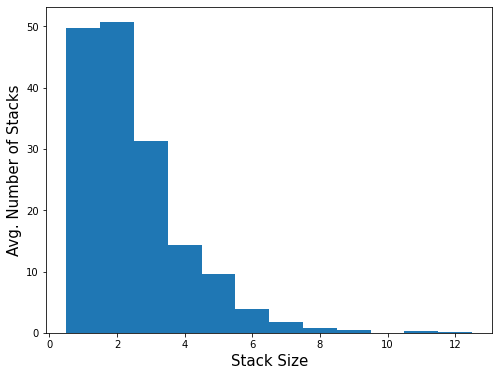

In [663]:
fig, ax = plt.subplots(1,1,figsize=(8,6))
ax.hist(sizes,bins=np.arange(0.5,maxsize+1.5,1),weights=(1/len(sizes_list))*np.ones(len(sizes)))
ax.set_xlabel("Stack Size",fontsize = 15)
ax.set_ylabel("Avg. Number of Stacks",fontsize = 15)

In [666]:
len(sizes_list)

252